In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv(
    "../data/cleaned_data.csv",
    parse_dates=["Order Date", "Ship Date"]
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   int64         
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

1. What is the total revenue generated by the business?

In [104]:
df['Sales'].sum()

np.float64(2261536.7827000003)

In [105]:
#BUSINESS INSIGHT: Total Revenue

# The business generated a total revenue of **$2.26 million** during the period covered by the dataset.
# This metric provides an overall measure of business performance and serves as a baseline KPI for comparing future sales trends across regions, products, and customer segments.

2. What is the average sales value per transaction?

In [106]:
df['Sales'].mean()

np.float64(230.7690594591837)

In [107]:
# The average sales value per transaction is $230.76. This metric provides an estimate of the typical order size and helps evaluate 
# customer spending behavior. It can also be used as a benchmark to assess the impact of pricing strategies, promotional campaigns, or changes in purchasing patterns over time.

3.How are sales distributed? Are there any outliers?

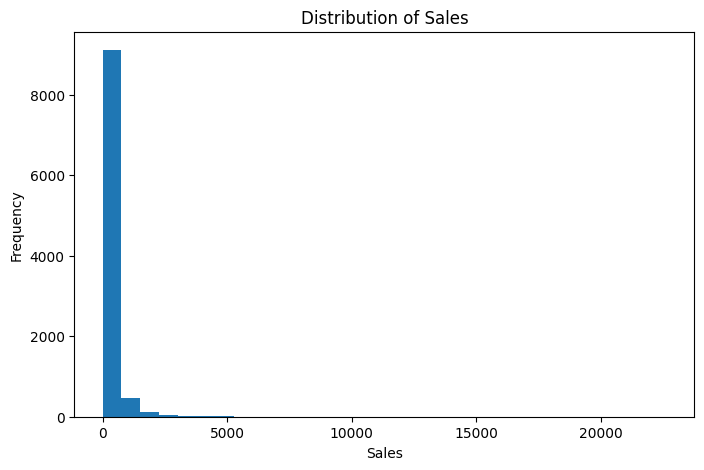

In [108]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [109]:
# The sales distribution is highly right-skewed, indicating that most transactions are low-value purchases, while a small number of high-value orders contribute significantly to total revenue. This suggests that although the business processes many
#  small orders, a few large transactions have a substantial impact on overall sales.

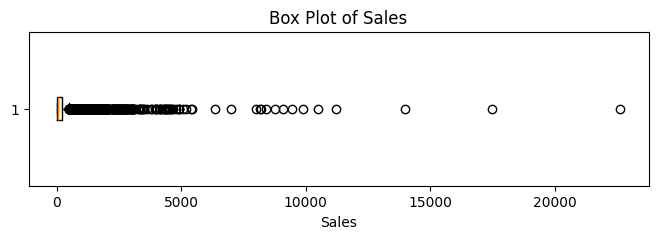

In [110]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Sales"], vert=False)

plt.title("Box Plot of Sales")

plt.xlabel("Sales")

plt.show()

In [111]:
# The box plot reveals numerous high-value outliers, indicating that a small number of transactions are significantly larger than the typical order size. These may represent bulk purchases or premium product orders and 
# can influence metrics such as the average sales value.

4.How have sales changed over time?

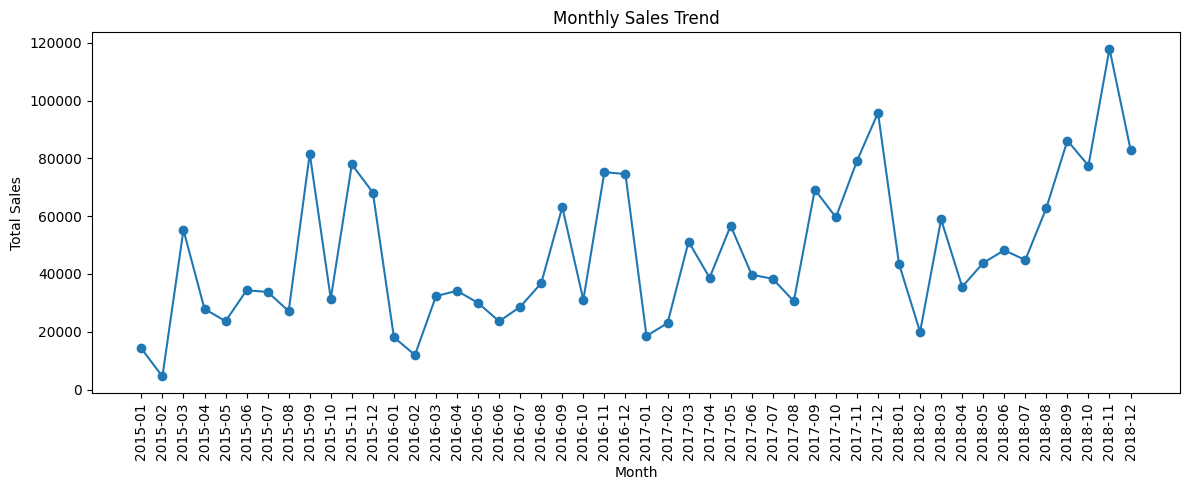

In [112]:
df["Month"] = df["Order Date"].dt.to_period("M")

trend = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))

plt.plot(trend["Month"].astype(str), trend["Sales"], marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [113]:
# ### Business Insight

# The monthly sales trend shows noticeable fluctuations throughout the analysis period, with recurring peaks and declines in revenue. Despite these short-term variations, sales exhibit an overall upward trend from 2015 to 2018, indicating steady business growth. The highest sales are observed towards the end of 2018, suggesting increasing customer demand and possible seasonal effects during the final months of the year. These insights can help the business 
# optimize inventory planning, marketing campaigns, and resource allocation during peak sales periods.

5: Which month generates the highest and lowest sales?

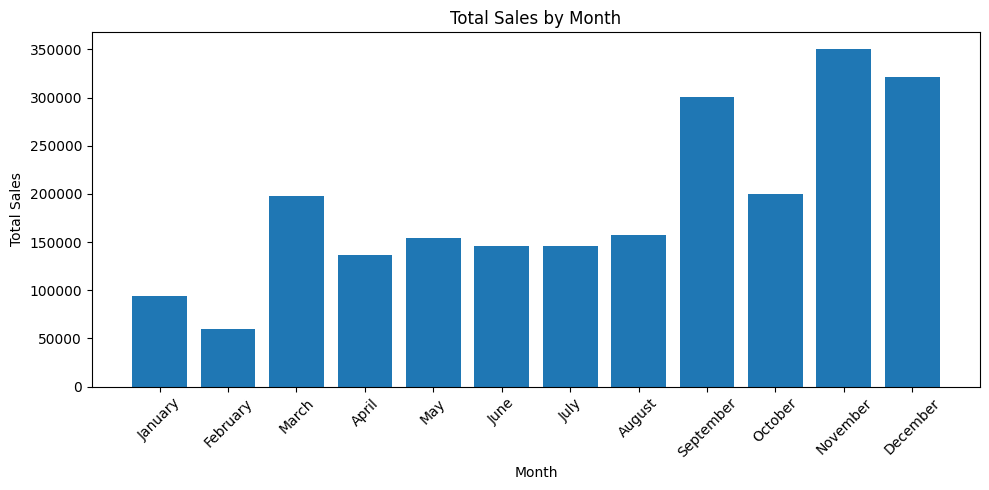

Highest Sales Month: November with Sales: $350161.71
Lowest Sales Month: February with Sales: $59371.12


In [114]:

df["Month_Number"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

monthly_sales = (
    df.groupby(["Month_Number", "Month_Name"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

plt.figure(figsize=(10, 5))

plt.bar(monthly_sales["Month_Name"], monthly_sales["Sales"])

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

highest_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["Sales"].idxmin()]
print(f"Highest Sales Month: {highest_month['Month_Name']} with Sales: ${highest_month['Sales']:.2f}")
print(f"Lowest Sales Month: {lowest_month['Month_Name']} with Sales: ${lowest_month['Sales']:.2f}")

In [115]:
# ### Business Insight

# Sales exhibit clear monthly variation, indicating seasonal purchasing behavior. 
# November recorded the highest total sales, while February generated the lowest sales. 
# These patterns can help the business optimize inventory management, promotional campaigns, and staffing by preparing for 
# high-demand periods and implementing targeted strategies during slower months.

6. Which region contributes the highest sales?

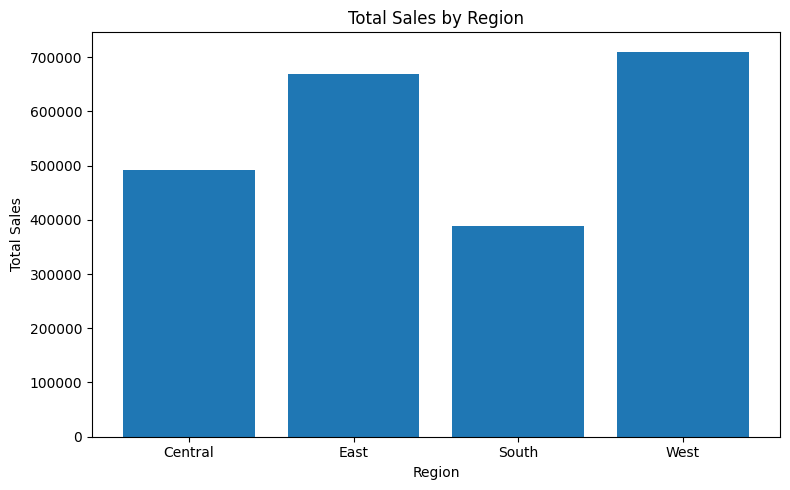

Highest Sales Region: Central with Sales: $492646.91
Lowest Sales Region: West with Sales: $710219.68


In [116]:

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(region_sales["Region"], region_sales["Sales"])

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

highest_region = region_sales.iloc[0]
lowest_region = region_sales.iloc[-1]
print(f"Highest Sales Region: {highest_region['Region']} with Sales: ${highest_region['Sales']:.2f}")
print(f"Lowest Sales Region: {lowest_region['Region']} with Sales: ${lowest_region['Sales']:.2f}")

In [117]:

# The West region generated the highest total sales, indicating strong customer demand and market 
# performance in this area. In contrast, the South region contributed the least revenue, suggesting 
# potential opportunities to improve market penetration through targeted marketing, inventory optimization, or customer
#  engagement strategies.

7: Which states generate the highest revenue?

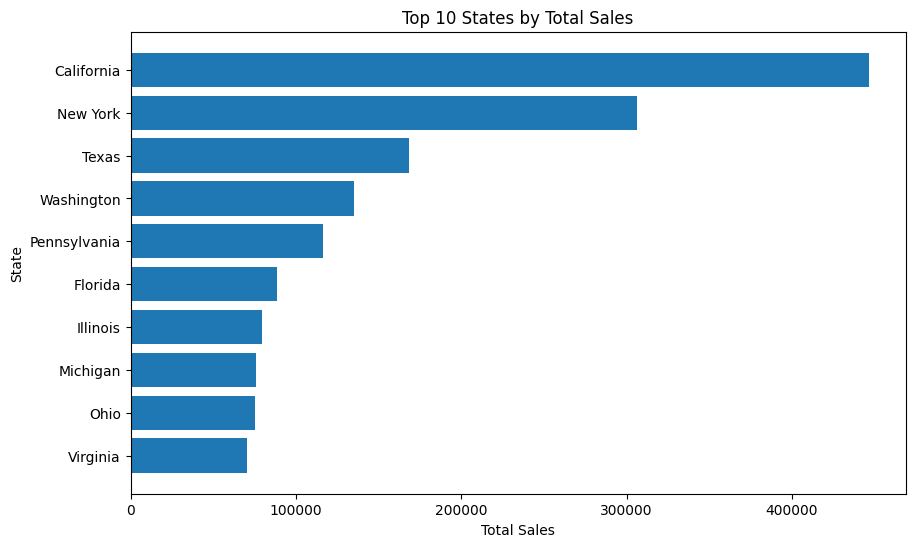

,State,Sales
0,California,446306.4635
1,New York,306361.1470
2,Texas,168572.5322
3,Washington,135206.8500
4,Pennsylvania,116276.6500
5,Florida,88436.5320
6,Illinois,79236.5170
7,Michigan,76136.0740
8,Ohio,75130.3500
9,Virginia,70636.7200


In [118]:

state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)


plt.figure(figsize=(10,6))

plt.barh(state_sales["State"], state_sales["Sales"])

plt.title("Top 10 States by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.gca().invert_yaxis()  

plt.show()

state_sales


In [119]:
# The top 10 states contribute a significant share of the company's total revenue. 
# California is the highest-performing state, indicating a strong customer base and market demand. Focusing on customer retention and continued investment in these high-performing states can help sustain revenue growth, 
# while analyzing lower-performing states may reveal opportunities for market expansion.

8: Which cities generate the highest revenue?

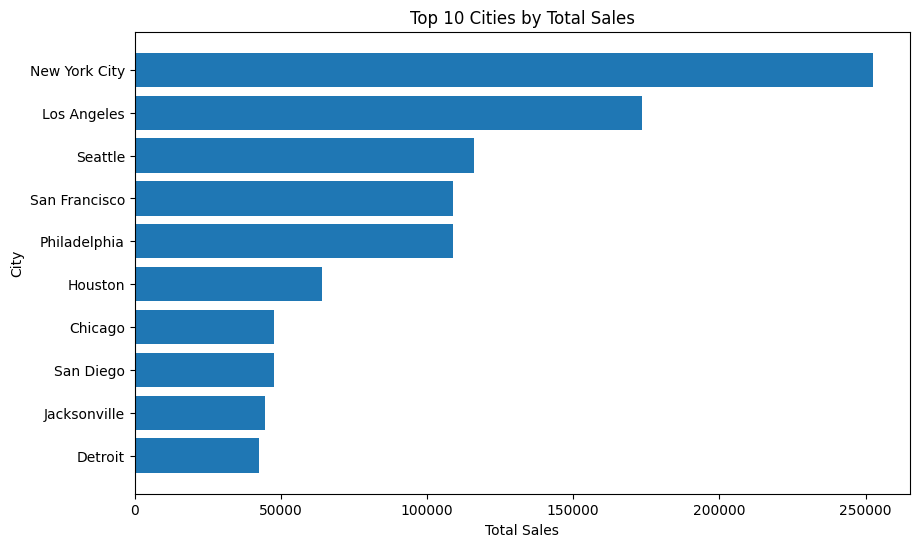

,City,Sales
0,New York City,252462.5470
1,Los Angeles,173420.1810
2,Seattle,116106.3220
3,San Francisco,109041.1200
4,Philadelphia,108841.7490
5,Houston,63956.1428
6,Chicago,47820.1330
7,San Diego,47521.0290
8,Jacksonville,44713.1830
9,Detroit,42446.9440


In [120]:

city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))

plt.barh(city_sales["City"], city_sales["Sales"])

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.gca().invert_yaxis()  

plt.show()

city_sales


9. Which product category generates the highest sales?

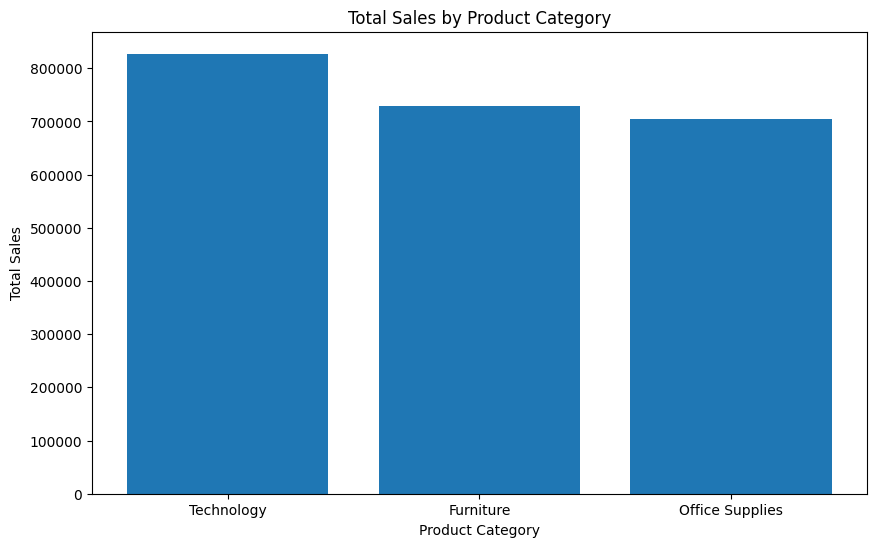

In [121]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
plt.figure(figsize=(10,6))

plt.bar(category_sales["Category"], category_sales["Sales"])

plt.title("Total Sales by Product Category")
plt.ylabel("Total Sales")
plt.xlabel("Product Category")


plt.show()



In [122]:
# The Technology category generated the highest total sales, making it the primary contributor to the
#  company's revenue. This suggests strong customer demand for products in this category. The lower-performing categories present opportunities for targeted marketing, 
# product assortment optimization, or promotional strategies to improve sales performance.

10. Which sub-category performs the best?

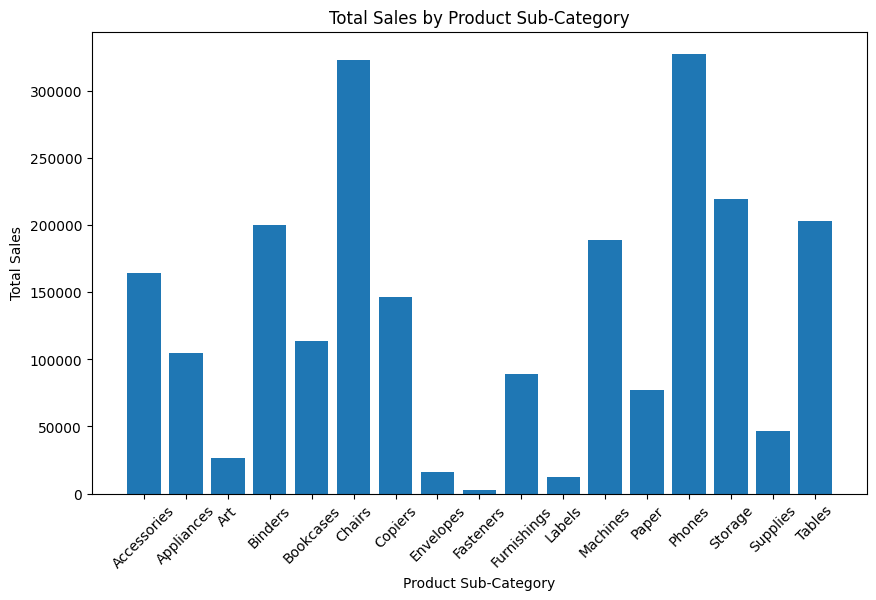

In [123]:
sub_category_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(10,6))

plt.bar(sub_category_sales["Sub-Category"], sub_category_sales["Sales"])

plt.title("Total Sales by Product Sub-Category")
plt.ylabel("Total Sales")
plt.xlabel("Product Sub-Category")
plt.xticks(rotation=45)

plt.show()



In [124]:
# Sales vary significantly across product sub-categories. Phones generated the highest revenue,
#  indicating strong customer demand and making it a key contributor to overall sales. In contrast, 
# Envelopes contributed the least revenue, suggesting opportunities to improve product visibility,
#  promotional efforts, or inventory strategy for underperforming products.

12. Which customer segment contributes the most revenue?

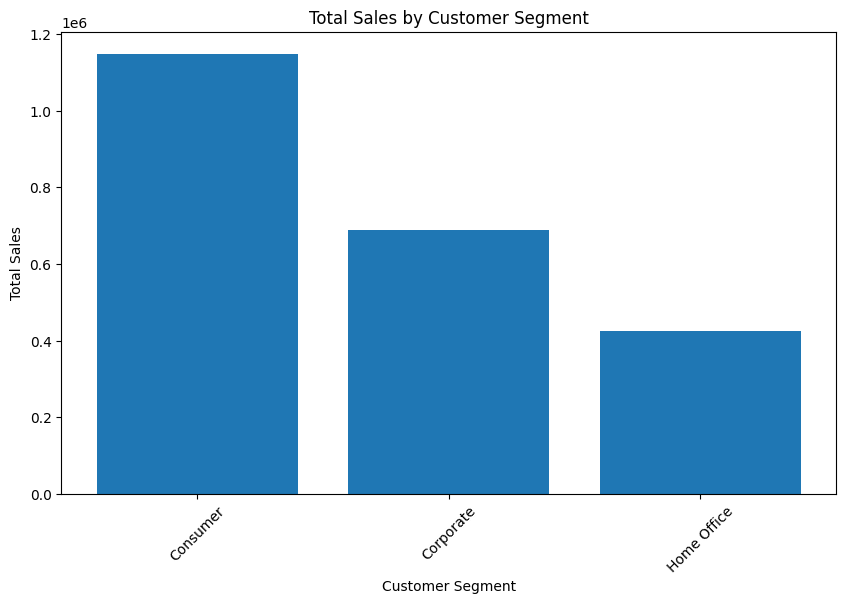

In [125]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(10,6))

plt.bar(segment_sales["Segment"], segment_sales["Sales"])

plt.title("Total Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.xlabel("Customer Segment")
plt.xticks(rotation=45)

plt.show()



In [126]:
# ### Business Insight

# The Consumer segment generated the highest total sales, making it the company's primary source of revenue.
#  This indicates that individual customers form the largest customer base and should remain a key focus for marketing,
#   customer retention, and promotional campaigns. While the Corporate and Home Office segments contribute less
#    to overall sales, they present opportunities
#  for targeted strategies and specialized product offerings to increase revenue.

13. Who are the top 10 customers by total sales?

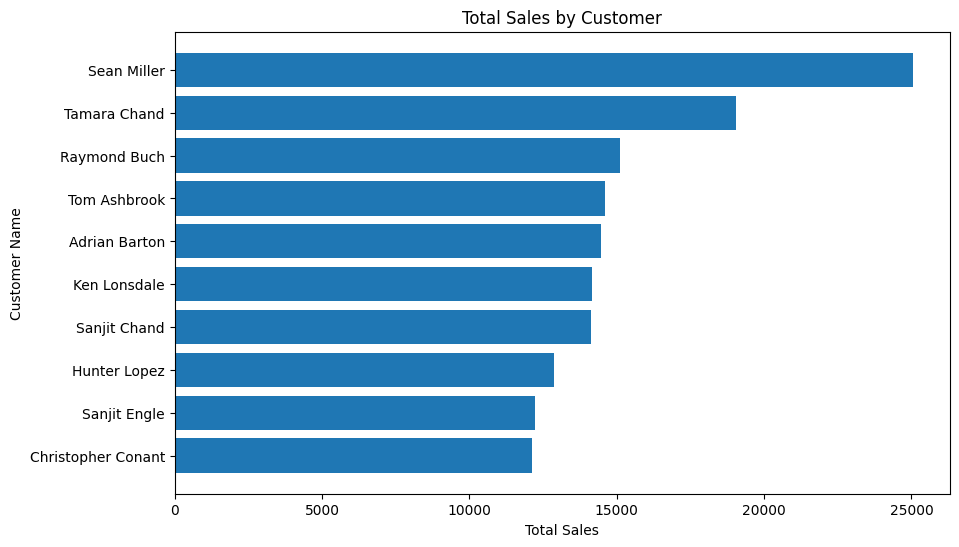

In [127]:
customer_sales = (
    df.groupby(["Customer ID","Customer Name"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
plt.figure(figsize=(10,6))

plt.barh(customer_sales["Customer Name"], customer_sales["Sales"])

plt.title("Total Sales by Customer")
plt.ylabel("Customer Name")
plt.xlabel("Total Sales")

plt.gca().invert_yaxis()  

plt.show()



In [128]:


# The top 10 customers contribute a significant portion of the company's total revenue, indicating that a relatively
#  small group of customers has a substantial impact on business performance. Retaining these high-value customers 
#  through loyalty programs, personalized offers, 
# and excellent customer service can help sustain long-term revenue growth while reducing customer churn.

14. Which shipping mode is used most frequently?

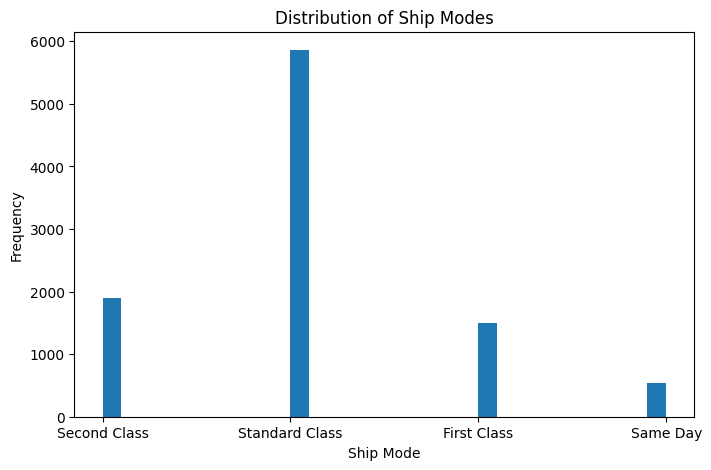

In [129]:
plt.figure(figsize=(8,5))

plt.hist(df["Ship Mode"], bins=30)

plt.title("Distribution of Ship Modes")
plt.xlabel("Ship Mode")
plt.ylabel("Frequency")

plt.show()

In [130]:

# The most frequently used shipping mode reflects customer preference for balancing delivery speed and shipping cost.
#  Understanding this preference enables the business to optimize logistics operations, improve delivery
#  efficiency, and negotiate better shipping rates while ensuring customer satisfaction.

15. What is the average shipping time, and how does it vary by shipping mode?

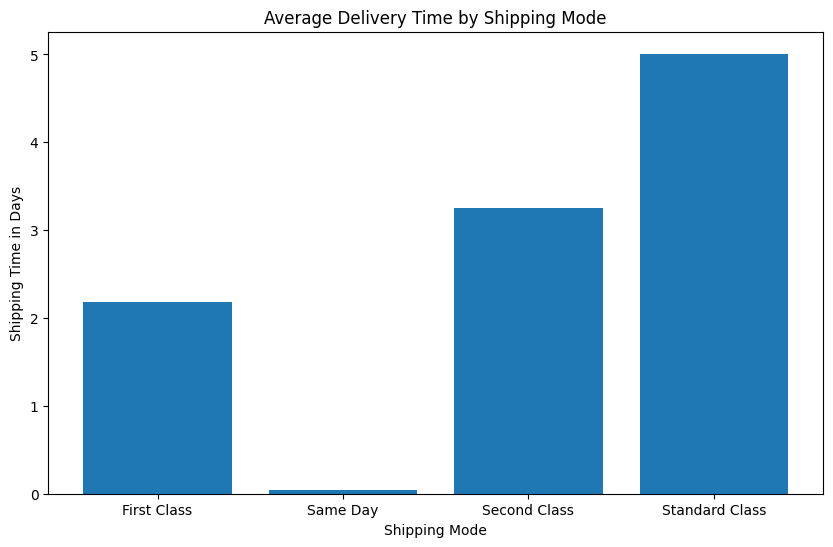

In [131]:
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df=df.groupby("Ship Mode")["Delivery Days"].mean().reset_index()

plt.figure(figsize=(10,6))

plt.bar(df["Ship Mode"], df["Delivery Days"])

plt.title("Average Delivery Time by Shipping Mode")
plt.ylabel("Shipping Time in Days")
plt.xlabel("Shipping Mode")
 

plt.show()



In [132]:

# The average shipping time provides an important measure of operational efficiency. A consistently low 
# delivery time indicates an effective supply chain and fulfillment process, while longer delivery times may negatively
#  affect customer satisfaction. Monitoring shipping performance across different shipping modes can help identify 
#  opportunities to improve delivery speed and overall customer experience.



## Final Business Summary

The exploratory data analysis provides a comprehensive understanding of the company's sales performance, customer behavior, product demand, geographic distribution, and operational efficiency. Revenue is primarily driven by high-performing regions, states, product categories, and customer segments, while sales exhibit seasonal fluctuations throughout the year.

The analysis also reveals that a relatively small number of products and customers contribute disproportionately to total revenue, highlighting opportunities for targeted customer retention and inventory optimization. Shipping analysis provides valuable insights into customer delivery preferences and fulfillment efficiency.

Overall, these findings support data-driven decision-making in areas such as marketing strategy, inventory management, customer relationship management, logistics optimization, and business expansion. The insights generated during EDA establish a strong foundation for feature engineering, predictive analytics, interactive dashboard development, and future machine learning applications.